In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

import sys, os

# sys.path.append(os.path.join(os.getcwd(), "../rctorch"))


from rctorch.models import MorrisLecar, MorrisLecarCurrent

from warnings import filterwarnings

filterwarnings("ignore")

In [2]:
mpl.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["font.family"] = "Nimbus Roman"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["figure.titlesize"] = 14
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False

In [3]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

In [4]:
Ne = 1
Ni = 1
N = Ne + Ni

T = 1000.0
dt = 0.1
t = np.arange(0, T, dt)
steps = t.size

model = MorrisLecar

base_kwargs = {
    "Ne": Ne,
    "Ni": Ni,
    "dt": dt,
    "BIAS": torch.ones(size=(N, 1)) * 90.0,
    "gbar": 0,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if model is MorrisLecarCurrent:
    base_kwargs["p_sparsity"] = 0.1

In [5]:
ml = model(**base_kwargs)

mem_rec = np.zeros(shape=(steps, N, 1))
n_rec = np.zeros(shape=(steps, N, 1))
s_rec = np.zeros(shape=(steps, N, 1))

for i in tqdm(range(steps)):
    ml.forward(0)
    mem_rec[i] = ml.mem.cpu().numpy()
    n_rec[i] = ml.n.cpu().numpy()
    s_rec[i] = ml.s.cpu().numpy()    

100%|██████████| 10000/10000 [00:04<00:00, 2469.53it/s]


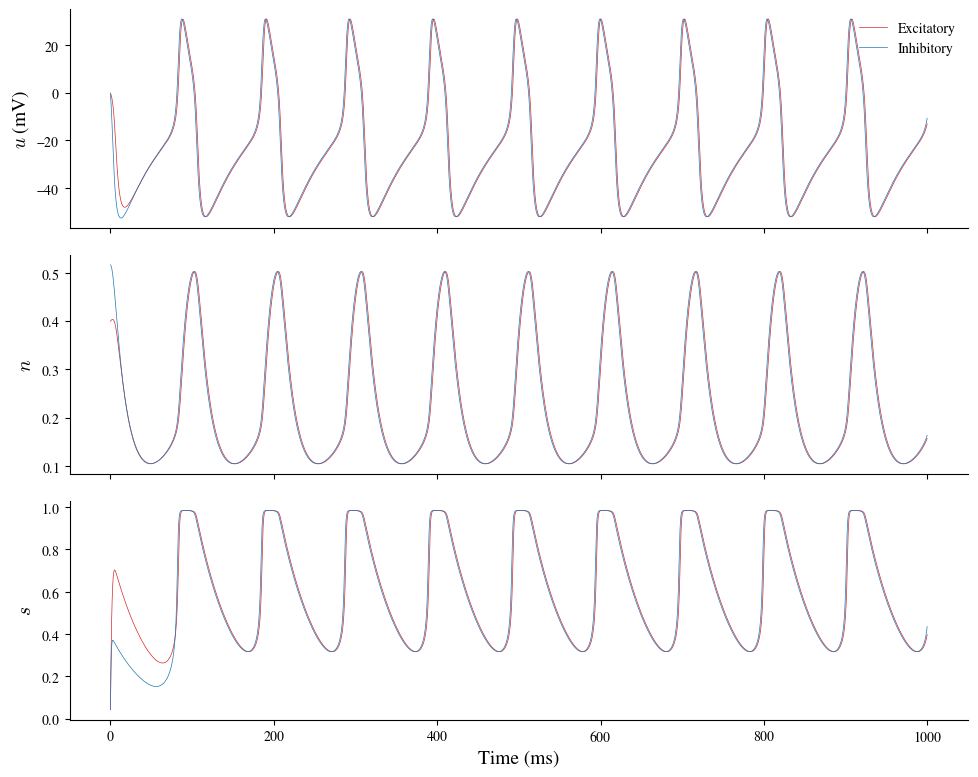

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(t, mem_rec[:, 0], color="tab:red", lw=0.5)
ax[0].set_ylabel(r"$u$ (mV)")
ax[1].plot(t, n_rec[:, 0], color="tab:red", lw=0.5)
ax[1].set_ylabel(r"$n$")
ax[2].plot(t, s_rec[:, 0], color="tab:red", lw=0.5)
ax[2].set_ylabel(r"$s$")
ax[2].set_xlabel("Time (ms)")
ax[0].plot(t, mem_rec[:, 1], color="tab:blue", lw=0.5)
ax[1].plot(t, n_rec[:, 1], color="tab:blue", lw=0.5)
ax[2].plot(t, s_rec[:, 1], color="tab:blue", lw=0.5)
ax[0].legend(["Excitatory", "Inhibitory"], loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

In [7]:
sensitive_kwargs = base_kwargs.copy()
sensitive_kwargs['k_p'] = 1.0
sensitive_kwargs['v_t'] = -20.0

numb_kwargs = base_kwargs.copy()
numb_kwargs['k_p'] = 25.0
numb_kwargs['v_t'] = 15.0

In [9]:
ml = model(**base_kwargs)
ml_sensitive = model(**sensitive_kwargs)
ml_numb = model(**numb_kwargs)

ml_sensitive.mem = ml.mem.clone()
ml_sensitive.n = ml.n.clone()
ml_sensitive.s = ml.s.clone()
ml_sensitive.w = ml.w.clone()

ml_numb.mem = ml.mem.clone()
ml_numb.n = ml.n.clone()
ml_numb.s = ml.s.clone()
ml_numb.w = ml.w.clone()

mem_rec_base = np.zeros(shape=(steps, N, 1))
mem_rec_sensitive = np.zeros(shape=(steps, N, 1))
mem_rec_numb = np.zeros(shape=(steps, N, 1))

s_rec_base = np.zeros(shape=(steps, N, 1))
s_rec_sensitive = np.zeros(shape=(steps, N, 1))
s_rec_numb = np.zeros(shape=(steps, N, 1))

for i in tqdm(range(steps)):
    ml.forward(0)
    ml_sensitive.forward(0)
    ml_numb.forward(0)
    
    mem_rec_base[i] = ml.mem.cpu().numpy()    
    mem_rec_sensitive[i] = ml_sensitive.mem.cpu().numpy()
    mem_rec_numb[i] = ml_numb.mem.cpu().numpy()

    s_rec_base[i] = ml.s.cpu().numpy()    
    s_rec_sensitive[i] = ml_sensitive.s.cpu().numpy()    
    s_rec_numb[i] = ml_numb.s.cpu().numpy()


100%|██████████| 10000/10000 [00:11<00:00, 857.24it/s]


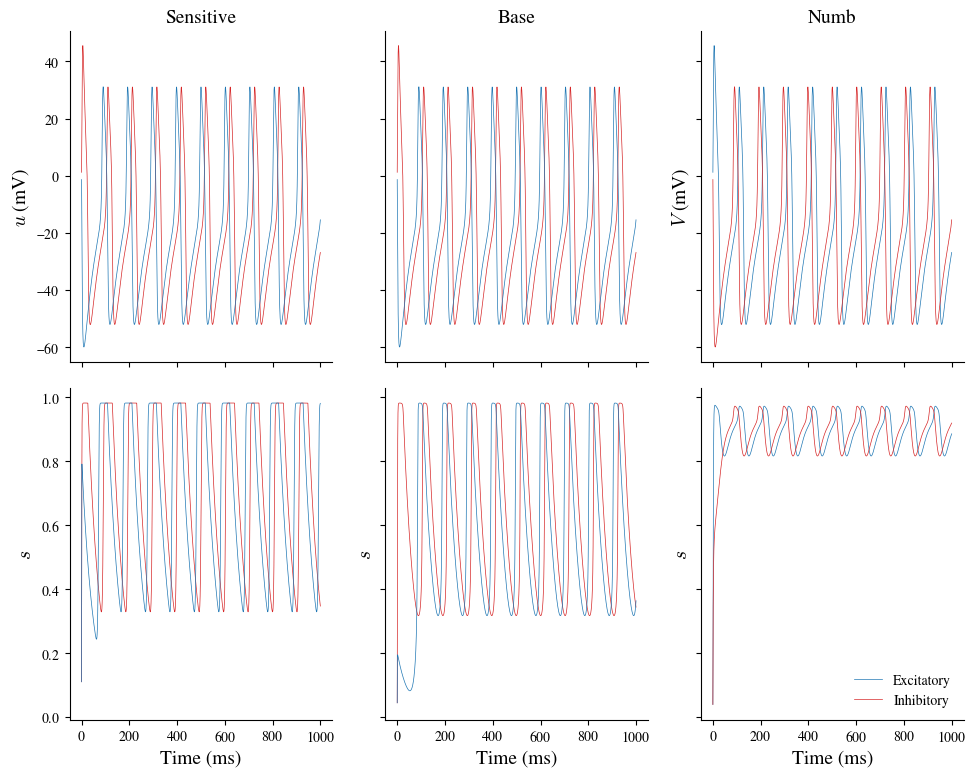

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(10, 8), sharex=True, sharey='row')
ax[0, 0].plot(t, mem_rec_sensitive[:, 0], color="tab:red", lw=0.5)
ax[0, 0].set_ylabel(r"$u$ (mV)")
ax[1, 0].plot(t, s_rec_sensitive[:, 0], color="tab:red", lw=0.5)
ax[1, 0].set_ylabel(r"$s$")
ax[1, 0].set_xlabel("Time (ms)")
ax[0, 2].plot(t, mem_rec_numb[:, 0], color="tab:blue", lw=0.5)
ax[0, 2].set_ylabel(r"$V$ (mV)")
ax[1, 2].plot(t, s_rec_numb[:, 0], color="tab:blue", lw=0.5)
ax[1, 2].set_ylabel(r"$s$")
ax[1, 2].set_xlabel("Time (ms)")
ax[0, 0].set_title("Sensitive")
ax[0, 2].set_title("Numb")
ax[0, 1].set_title("Base")
ax[0, 1].plot(t, mem_rec_base[:, 0], color="tab:red", lw=0.5)
ax[1, 1].plot(t, s_rec_base[:, 0], color="tab:red", lw=0.5)
ax[1, 1].set_ylabel(r"$s$")
ax[1, 1].set_xlabel("Time (ms)")
ax[0, 0].plot(t, mem_rec_sensitive[:, 1], color="tab:blue", lw=0.5)
ax[1, 0].plot(t, s_rec_sensitive[:, 1], color="tab:blue", lw=0.5)
ax[0, 2].plot(t, mem_rec_numb[:, 1], color="tab:red", lw=0.5)
ax[1, 2].plot(t, s_rec_numb[:, 1], color="tab:red", lw=0.5)
ax[0, 1].plot(t, mem_rec_base[:, 1], color="tab:blue", lw=0.5)
ax[1, 1].plot(t, s_rec_base[:, 1], color="tab:blue", lw=0.5)
ax[1, 2].legend(["Excitatory", "Inhibitory"], loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

In [14]:
#@title Different parameter sets
Ne = 80
Ni = 20
N = Ne + Ni

model = MorrisLecarCurrent


base_kwargs = {
    "Ne": Ne,
    "Ni": Ni,
    "dt": 1e-1,
    "BIAS": torch.ones(size=(N, 1)) * 75,
    "gbar": 30,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

if model is MorrisLecarCurrent:
    base_kwargs['p_sparsity'] = 0.05

normal = base_kwargs | {
    "k_p": 5,
    "v_t": 2,
}



sensitive = base_kwargs | {
    "k_p": 1,
    "v_t": 2,
}

insensitive = base_kwargs | {
    "k_p": 10,
    "v_t": 2,
}

low_thresh = base_kwargs | {
    "k_p": 5,
    "v_t": -10,
}

high_thresh = base_kwargs | {
    "k_p": 5,
    "v_t": 10,
}

low_thresh_sensitive = base_kwargs | {
    "k_p": 1,
    "v_t": -10,
}

high_thresh_sensitive = base_kwargs | {
    "k_p": 1,
    "v_t": 10,
}

low_thresh_insensitive = base_kwargs | {
    "k_p": 10,
    "v_t": -10,
}

high_thresh_insensitive = base_kwargs | {
    "k_p": 10,
    "v_t": 10,
}

In [15]:
T = 1000  # [ms]
nt = int(T / base_kwargs["dt"])

t = np.arange(0, T, base_kwargs["dt"])

In [16]:
ml_normal = model(**normal)
ml_sensitive = model(**sensitive)
ml_insensitive = model(**insensitive)
ml_low_thresh = model(**low_thresh)
ml_high_thresh = model(**high_thresh)
ml_low_thresh_sensitive = model(**low_thresh_sensitive)
ml_high_thresh_sensitive = model(**high_thresh_sensitive)
ml_low_thresh_insensitive = model(**low_thresh_insensitive)
ml_high_thresh_insensitive = model(**high_thresh_insensitive)

ml_sensitive.mem = ml_normal.mem.clone()
ml_insensitive.mem = ml_normal.mem.clone()
ml_sensitive.s = ml_normal.s.clone()
ml_insensitive.s = ml_normal.s.clone()
ml_sensitive.n = ml_normal.n.clone()
ml_insensitive.n = ml_normal.n.clone()
ml_low_thresh.mem = ml_normal.mem.clone()
ml_high_thresh.mem = ml_normal.mem.clone()
ml_low_thresh_sensitive.mem = ml_normal.mem.clone()
ml_high_thresh_sensitive.mem = ml_normal.mem.clone()
ml_low_thresh_insensitive.mem = ml_normal.mem.clone()
ml_high_thresh_insensitive.mem = ml_normal.mem.clone()

ml_low_thresh.s = ml_normal.s.clone()
ml_high_thresh.s = ml_normal.s.clone()
ml_low_thresh_sensitive.s = ml_normal.s.clone()
ml_high_thresh_sensitive.s = ml_normal.s.clone()
ml_low_thresh_insensitive.s = ml_normal.s.clone()
ml_high_thresh_insensitive.s = ml_normal.s.clone()

ml_low_thresh.n = ml_normal.n.clone()
ml_high_thresh.n = ml_normal.n.clone()
ml_low_thresh_sensitive.n = ml_normal.n.clone()
ml_high_thresh_sensitive.n = ml_normal.n.clone()
ml_low_thresh_insensitive.n = ml_normal.n.clone()
ml_high_thresh_insensitive.n = ml_normal.n.clone()

ml_sensitive.w = ml_normal.w.clone()
ml_insensitive.w = ml_normal.w.clone()
ml_low_thresh.w = ml_normal.w.clone()
ml_high_thresh.w = ml_normal.w.clone()
ml_low_thresh_sensitive.w = ml_normal.w.clone()
ml_high_thresh_sensitive.w = ml_normal.w.clone()
ml_low_thresh_insensitive.w = ml_normal.w.clone()
ml_high_thresh_insensitive.w = ml_normal.w.clone()

n_saved = 5  # number of neurons to save for plotting

mem_rec_normal = torch.zeros(size=(nt, n_saved))
s_rec_normal = torch.zeros(size=(nt, n_saved))
n_rec_normal = torch.zeros(size=(nt, n_saved))

mem_rec_sensitive = torch.zeros(size=(nt, n_saved))
s_rec_sensitive = torch.zeros(size=(nt, n_saved))
n_rec_sensitive = torch.zeros(size=(nt, n_saved))

mem_rec_insensitive = torch.zeros(size=(nt, n_saved))
s_rec_insensitive = torch.zeros(size=(nt, n_saved))
n_rec_insensitive = torch.zeros(size=(nt, n_saved))

mem_rec_low_thresh = torch.zeros(size=(nt, n_saved))
s_rec_low_thresh = torch.zeros(size=(nt, n_saved))
n_rec_low_thresh = torch.zeros(size=(nt, n_saved))

mem_rec_high_thresh = torch.zeros(size=(nt, n_saved))
s_rec_high_thresh = torch.zeros(size=(nt, n_saved))
n_rec_high_thresh = torch.zeros(size=(nt, n_saved))

mem_rec_low_thresh_sensitive = torch.zeros(size=(nt, n_saved))
s_rec_low_thresh_sensitive = torch.zeros(size=(nt, n_saved))
n_rec_low_thresh_sensitive = torch.zeros(size=(nt, n_saved))

mem_rec_high_thresh_sensitive = torch.zeros(size=(nt, n_saved))
s_rec_high_thresh_sensitive = torch.zeros(size=(nt, n_saved))
n_rec_high_thresh_sensitive = torch.zeros(size=(nt, n_saved))

mem_rec_low_thresh_insensitive = torch.zeros(size=(nt, n_saved))
s_rec_low_thresh_insensitive = torch.zeros(size=(nt, n_saved))
n_rec_low_thresh_insensitive = torch.zeros(size=(nt, n_saved))

mem_rec_high_thresh_insensitive = torch.zeros(size=(nt, n_saved))
s_rec_high_thresh_insensitive = torch.zeros(size=(nt, n_saved))
n_rec_high_thresh_insensitive = torch.zeros(size=(nt, n_saved))


for i in tqdm(range(nt)):
    ml_normal.forward(0)
    ml_sensitive.forward(0)
    ml_insensitive.forward(0)
    ml_low_thresh.forward(0)
    ml_high_thresh.forward(0)
    ml_low_thresh_sensitive.forward(0)
    ml_high_thresh_sensitive.forward(0)
    ml_low_thresh_insensitive.forward(0)
    ml_high_thresh_insensitive.forward(0)

    mem_rec_normal[i] = ml_normal.mem[:n_saved].squeeze().detach().cpu()
    s_rec_normal[i] = ml_normal.s[:n_saved].squeeze().detach().cpu()
    n_rec_normal[i] = ml_normal.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_sensitive[i] = ml_sensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_sensitive[i] = ml_sensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_sensitive[i] = ml_sensitive.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_insensitive[i] = ml_insensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_insensitive[i] = ml_insensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_insensitive[i] = ml_insensitive.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_low_thresh[i] = ml_low_thresh.mem[:n_saved].squeeze().detach().cpu()
    s_rec_low_thresh[i] = ml_low_thresh.s[:n_saved].squeeze().detach().cpu()
    n_rec_low_thresh[i] = ml_low_thresh.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_high_thresh[i] = ml_high_thresh.mem[:n_saved].squeeze().detach().cpu()
    s_rec_high_thresh[i] = ml_high_thresh.s[:n_saved].squeeze().detach().cpu()
    n_rec_high_thresh[i] = ml_high_thresh.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_low_thresh_sensitive[i] = ml_low_thresh_sensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_low_thresh_sensitive[i] = ml_low_thresh_sensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_low_thresh_sensitive[i] = ml_low_thresh_sensitive.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_high_thresh_sensitive[i] = ml_high_thresh_sensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_high_thresh_sensitive[i] = ml_high_thresh_sensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_high_thresh_sensitive[i] = ml_high_thresh_sensitive.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_low_thresh_insensitive[i] = ml_low_thresh_insensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_low_thresh_insensitive[i] = ml_low_thresh_insensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_low_thresh_insensitive[i] = ml_low_thresh_insensitive.n[:n_saved].squeeze().detach().cpu()
    
    mem_rec_high_thresh_insensitive[i] = ml_high_thresh_insensitive.mem[:n_saved].squeeze().detach().cpu()
    s_rec_high_thresh_insensitive[i] = ml_high_thresh_insensitive.s[:n_saved].squeeze().detach().cpu()
    n_rec_high_thresh_insensitive[i] = ml_high_thresh_insensitive.n[:n_saved].squeeze().detach().cpu()

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:34<00:00, 287.57it/s]


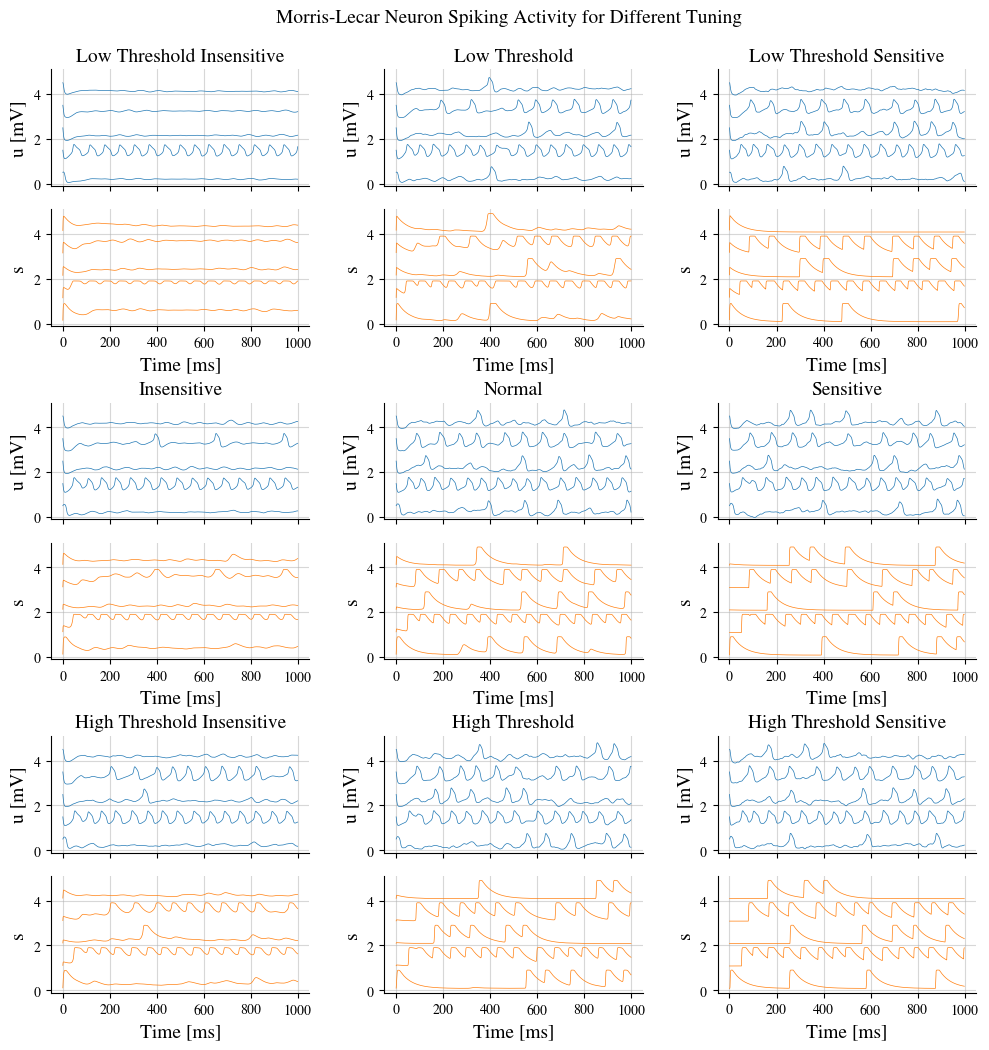

In [ ]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)


mem_min = -75
mem_max = 75
s_min = -0.1
s_max = 1.1
n_min = -0.1
n_max = 1.1

mem_diff = mem_max - mem_min
s_diff = s_max - s_min
n_diff = n_max - n_min

step = 10
t_steped = t[::step]


for i in range(3):
    for j in range(3):
        if i == 1 and j == 1:
            mem_rec = mem_rec_normal
            s_rec = s_rec_normal
            n_rec = n_rec_normal
            title = "Normal"
        elif i == 1 and j == 2:
            mem_rec = mem_rec_sensitive
            s_rec = s_rec_sensitive
            n_rec = n_rec_sensitive
            title = "Sensitive"
        elif i == 1 and j == 0:
            mem_rec = mem_rec_insensitive
            s_rec = s_rec_insensitive
            n_rec = n_rec_insensitive
            title = "Insensitive"
        elif i == 0 and j == 1:
            mem_rec = mem_rec_low_thresh
            s_rec = s_rec_low_thresh
            n_rec = n_rec_low_thresh
            title = "Low Threshold"
        elif i == 0 and j == 2:
            mem_rec = mem_rec_low_thresh_sensitive
            s_rec = s_rec_low_thresh_sensitive
            n_rec = n_rec_low_thresh_sensitive
            title = "Low Threshold Sensitive"
        elif i == 0 and j == 0:
            mem_rec = mem_rec_low_thresh_insensitive
            s_rec = s_rec_low_thresh_insensitive
            n_rec = n_rec_low_thresh_insensitive
            title = "Low Threshold Insensitive"
        elif i == 2 and j == 1:
            mem_rec = mem_rec_high_thresh
            s_rec = s_rec_high_thresh
            n_rec = n_rec_high_thresh
            title = "High Threshold"
        elif i == 2 and j == 2:
            mem_rec = mem_rec_high_thresh_sensitive
            s_rec = s_rec_high_thresh_sensitive
            n_rec = n_rec_high_thresh_sensitive
            title = "High Threshold Sensitive"
        elif i == 2 and j == 0:
            mem_rec = mem_rec_high_thresh_insensitive
            s_rec = s_rec_high_thresh_insensitive
            n_rec = n_rec_high_thresh_insensitive
            title = "High Threshold Insensitive"
        
        t = np.arange(0, T, base_kwargs["dt"])
        
        subfig = fig.add_subfigure(gs[i, j])
        axes = subfig.subplots(2, 1, sharex=True, sharey=True)
        

        for k in range(5):
            mem_norm = (mem_rec[::step, k] - mem_min) / mem_diff
            axes[0].plot(t_steped, mem_norm + k, color="tab:blue", lw=0.5)
            s_norm = (s_rec[::step, k] - s_min) / s_diff
            axes[1].plot(t_steped, s_norm + k, lw=0.5, color="tab:orange")
            # n_norm = (n_rec[::step, k] - n_min) / n_diff
            # axes[2].plot(t_steped, n_norm + k, lw=1)

        axes[1].set_xlabel("Time [ms]")

        axes[0].set_ylim(-0.1, 5.1)
        axes[1].set_ylim(-0.1, 5.1)
        # axes[2].set_ylim(-0.1, 5.1)
        axes[0].grid(alpha=0.5)
        axes[1].grid(alpha=0.5)
        # axes[2].grid(alpha=0.5)
        axes[0].set_title(title)
        axes[0].set_ylabel("u [mV]")
        axes[1].set_ylabel("s")
        # axes[2].set_ylabel("n")

plt.suptitle("Morris-Lecar Neuron Spiking Activity for Different Tuning", y=1.02)
# plt.tight_layout()
plt.show(fig)

In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider, fixed
from IPython.display import display
import torch

# interactive simulation + caching (cell 3)

# cache for computed simulations
_SIM_CACHE = {}
step = 10  # plot every `step` time step


def _simulate(k_p: float, v_t: float, num_plot: int = 5):
    """Run the Morris-Lecar model and return recordings for the first `num_plot` neurons.
    Results cached keyed by (k_p, v_t, num_plot). Uses torch.no_grad for speed.
    """
    key = (float(k_p), float(v_t), int(num_plot))
    if key in _SIM_CACHE:
        return _SIM_CACHE[key]

    kwargs = base_kwargs | {"k_p": k_p, "v_t": v_t}
    ml = MorrisLecar(**kwargs)

    # record only a small subset of neurons to avoid heavy CPU/memory usage
    mem_rec = torch.zeros(nt, num_plot)
    s_rec = torch.zeros(nt, num_plot)
    n_rec = torch.zeros(nt, num_plot)

    with torch.no_grad():
        for ti in tqdm(range(nt)):
            ml.forward(0)
            mem_rec[ti] = ml.mem[:num_plot, 0].cpu().squeeze()
            s_rec[ti] = ml.s[:num_plot, 0].cpu().squeeze()
            n_rec[ti] = ml.n[:num_plot, 0].cpu().squeeze()

    _SIM_CACHE[key] = (mem_rec, s_rec, n_rec)
    return _SIM_CACHE[key]


def _update_plot(k_p: float, v_t: float, num_plot: int = 5):
    mem_rec, s_rec, n_rec = _simulate(k_p, v_t, num_plot)

    # normalize each variable across time & neurons for plotting (matching previous style)
    mem_min = mem_rec.min()
    mem_max = mem_rec.max()
    mem_diff = (mem_max - mem_min).clamp(min=1e-6)

    s_min = s_rec.min()
    s_max = s_rec.max()
    s_diff = (s_max - s_min).clamp(min=1e-6)

    n_min = n_rec.min()
    n_max = n_rec.max()
    n_diff = (n_max - n_min).clamp(min=1e-6)

    t_steped_local = t[::step]

    fig, axes_local = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    for idx in range(num_plot):
        mem_norm = ((mem_rec[::step, idx] - mem_min) / mem_diff).numpy()
        s_norm = ((s_rec[::step, idx] - s_min) / s_diff).numpy()
        n_norm = ((n_rec[::step, idx] - n_min) / n_diff).numpy()

        axes_local[0].plot(t_steped_local, mem_norm + idx, lw=1)
        axes_local[1].plot(t_steped_local, s_norm + idx, lw=1)
        axes_local[2].plot(t_steped_local, n_norm + idx, lw=1)

    axes_local[0].set_ylabel("Membrane (norm + idx)")
    axes_local[1].set_ylabel("Synaptic (norm + idx)")
    axes_local[2].set_ylabel("Recovery (norm + idx)")
    axes_local[2].set_xlabel("Time [ms]")

    for ax in axes_local:
        ax.set_ylim(-0.1, num_plot + 0.1)
        ax.grid(alpha=0.4)

    plt.suptitle(f"Morris-Lecar (k_p={k_p}, v_t={v_t})")
    plt.tight_layout()
    plt.show()


# interactive sliders (defaults set to existing model_kwargs)
kp_slider = FloatSlider(value=float(model_kwargs["k_p"]), min=0.1, max=50.0, step=0.1, description="k_p")
vt_slider = FloatSlider(value=float(model_kwargs["v_t"]), min=-20.0, max=20.0, step=0.1, description="v_t")
num_slider = IntSlider(value=5, min=1, max=20, step=1, description="#neurons")

display(interact(_update_plot, k_p=kp_slider, v_t=vt_slider, num_plot=num_slider))